Linear Regression Questions

Task 1: Simple Linear Regression 

● Use the scikit-learn library. 

● Load the California Housing Dataset (or any house price dataset). 

● Predict the house price using a single feature (e.g., number of rooms). 

● Train a simple linear regression model. 

● Plot the regression line using matplotlib. 

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [12]:
data = fetch_california_housing()
X = data.data[:, [0]]  
y = data.target    
print(X)
print(y)    

[[8.3252]
 [8.3014]
 [7.2574]
 ...
 [1.7   ]
 [1.8672]
 [2.3886]]
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

[1.14958917 1.50606882 1.90393718 ... 4.31500772 1.612455   1.93412956]


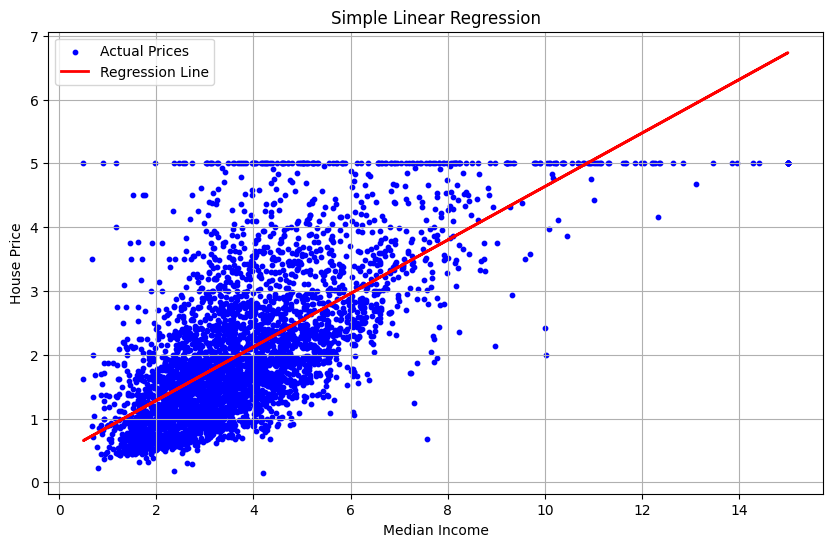

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue',s=10, label='Actual Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.title('Simple Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

Task 2: Multiple Linear Regression 
● Use the same dataset or load another dataset with at least 4 numeric 
features. 

● Predict the target variable using multiple independent variables. 

● Evaluate the model using: 

○ R-squared 

○ Mean Squared Error (MSE) 

○ Root Mean Squared Error (RMSE) 

● Display the coefficients of each feature.

In [16]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [17]:
data = fetch_california_housing()
X = data.data
y = data.target
print(X)
print(y)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(y_pred)

[0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]


In [19]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R-squared:", r2)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

for feature, coef in zip(data.feature_names, model.coef_):
    print(f"{feature}: {coef}")

R-squared: 0.5757877060324521
Mean Squared Error (MSE): 0.5558915986952425
Root Mean Squared Error (RMSE): 0.7455813830127751
MedInc: 0.44867490966571894
HouseAge: 0.009724257517905413
AveRooms: -0.12332334282795913
AveBedrms: 0.7831449067929733
Population: -2.029620580143443e-06
AveOccup: -0.0035263184871342293
Latitude: -0.41979248658835716
Longitude: -0.4337080649639876


Task 3: Feature Scaling and Normalization 

● Demonstrate the effect of standardizing features using 
StandardScaler. 

● Compare model performance before and after scaling.

In [20]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [21]:
data = fetch_california_housing()
X = data.data
y = data.target
print(X)
print(y)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
print(y_pred1)
print(y_test)

[0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]
[0.477   0.458   5.00001 ... 5.00001 0.723   1.515  ]


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model2 = LinearRegression()
model2.fit(X_train_scaled, y_train)
y_pred2 = model2.predict(X_test_scaled)
r2_before = r2_score(y_test, y_pred1)
r2_after = r2_score(y_test, y_pred2)

print("R-squared before scaling:", r2_before)
print("R-squared after scaling:", r2_after)

mse_before = mean_squared_error(y_test, y_pred1)
mse_after = mean_squared_error(y_test, y_pred2)

print("MSE before scaling:", mse_before)
print("MSE after scaling:", mse_after)

R-squared before scaling: 0.5757877060324521
R-squared after scaling: 0.575787706032451
MSE before scaling: 0.5558915986952425
MSE after scaling: 0.5558915986952442


Task 4: Model Interpretation 

● Write Python code to: 

○ Show the correlation matrix using a heatmap. 

○ Identify which features have the strongest relationship with 
the target. 

○ Discuss multicollinearity and how it might affect regression.

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [27]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  Target  
0        -12

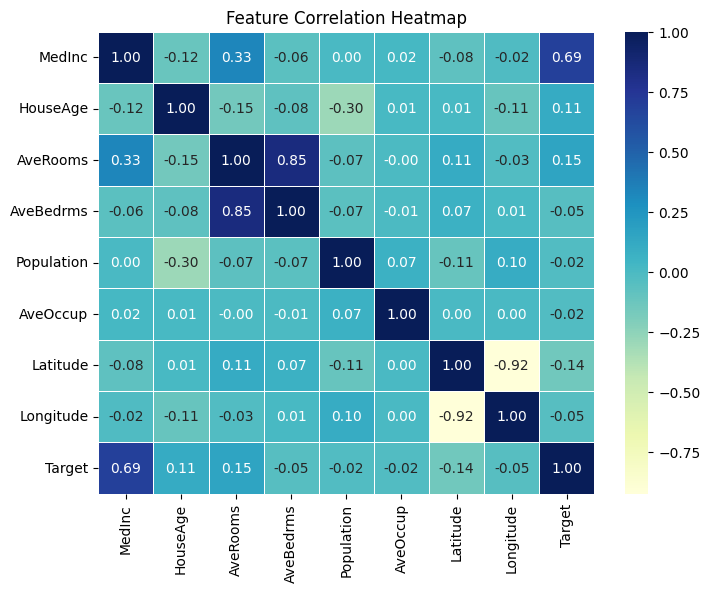

In [28]:
corr_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [30]:
cor_target = corr_matrix["Target"].drop("Target").sort_values(ascending=False)
print("Strongest correlations with Target:\n", cor_target)

Strongest correlations with Target:
 MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Target, dtype: float64



Logistic Regression Questions

Task 5: Binary Classification with Logistic Regression 

● Load the Breast Cancer Dataset from sklearn.datasets. 

● Train a logistic regression model to predict whether a tumor is 
benign or malignant. 

● Evaluate using: 

○ Accuracy 

○ Confusion Matrix 

○ Precision, Recall, F1-score
 
○ ROC-AUC curve

In [31]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [34]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)
print("ROC AUC Score:", roc_auc)

Accuracy: 0.956140350877193
Confusion Matrix:
 [[39  4]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC AUC Score: 0.9977071732721913


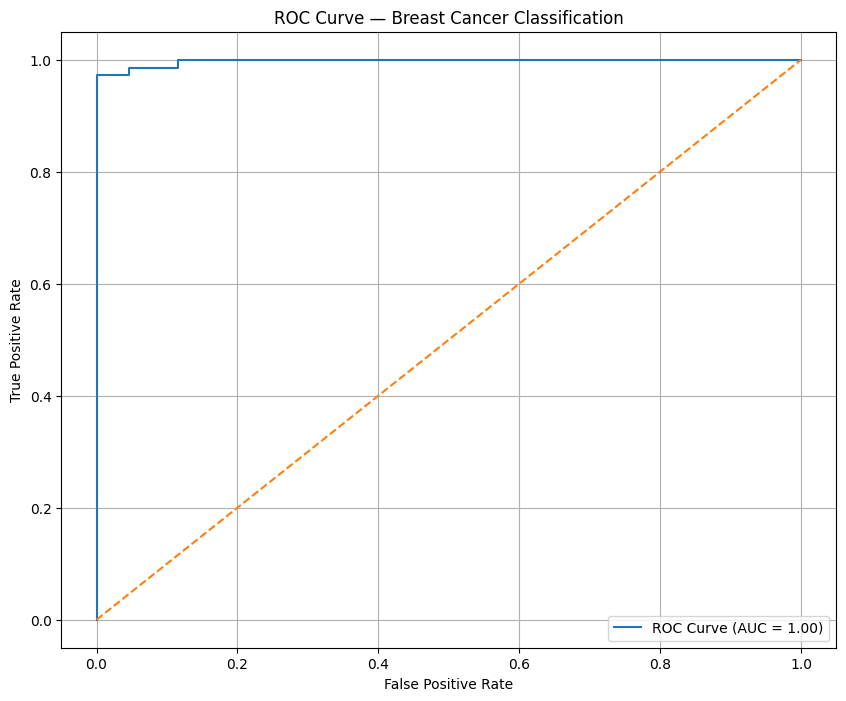

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Breast Cancer Classification')
plt.legend()
plt.grid()

Task 6: Threshold Tuning and Probability Interpretation 

● Predict the probability of the positive class. 

● Change the threshold (e.g., 0.3, 0.5, 0.7) and observe how the 
confusion matrix and F1-score change. 

● Plot the ROC curve and mark optimal threshold. 

In [36]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

In [37]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]
print(y_probs)

[8.78417737e-01 3.04735433e-08 1.59969809e-03 9.98775726e-01
 9.99858607e-01 2.00253498e-10 6.15347950e-11 1.92820681e-02
 9.84264981e-01 9.94311003e-01 9.29270359e-01 8.09446888e-04
 9.88907827e-01 1.76075741e-01 9.99212570e-01 1.74968272e-03
 9.98803857e-01 9.99987939e-01 9.99999387e-01 7.22142596e-07
 8.27778678e-01 9.92295256e-01 6.21088494e-09 9.99662491e-01
 9.96530414e-01 9.99758501e-01 9.98974884e-01 9.98978180e-01
 9.95311622e-01 7.41846222e-09 9.98535358e-01 9.99762181e-01
 9.99107461e-01 9.86395780e-01 9.99883544e-01 9.99050996e-01
 2.07437025e-03 9.98986277e-01 1.00852442e-05 7.18898594e-01
 9.99782212e-01 6.22986310e-04 9.99539044e-01 9.96009202e-01
 9.99756991e-01 9.82900274e-01 9.99967920e-01 9.99522850e-01
 9.59469632e-01 9.98578390e-01 9.47005926e-05 2.91077079e-09
 8.61050080e-01 9.99608713e-01 9.99399476e-01 9.86139467e-01
 9.99866373e-01 3.78444071e-12 7.26690273e-01 9.99943047e-01
 9.85647935e-01 7.80096190e-07 1.64719332e-09 9.19484277e-01
 9.97331188e-01 8.964434

In [38]:
thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"\nThreshold: {t}")
    print("Confusion Matrix:\n", cm)
    print("F1 Score:", round(f1, 3))

fpr, tpr, thr = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)


Threshold: 0.3
Confusion Matrix:
 [[39  4]
 [ 1 70]]
F1 Score: 0.966

Threshold: 0.5
Confusion Matrix:
 [[39  4]
 [ 1 70]]
F1 Score: 0.966

Threshold: 0.7
Confusion Matrix:
 [[41  2]
 [ 1 70]]
F1 Score: 0.979


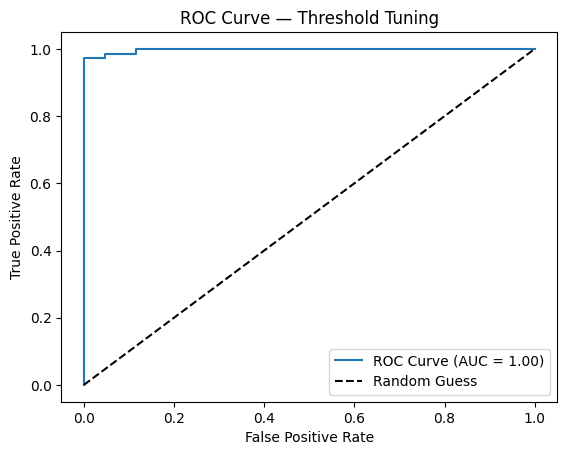

In [39]:
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Threshold Tuning')
plt.legend()